# Overfitting y tamaño del set de entrenamiento

En este notebook comparamos dos modelos —Random Forest y una red neuronal— sobre dos representaciones de la misma secuencia: **composición + fisicoquímicos** (los 20 aminoácidos + 13 features fisicoquímicos) y **composición + fisicoquímicos + señales** (esos mismos más las 11 señales posicionales: péptido señal, NLS y TMD).

Entrenamos con **250, 750, 1500 y 3000 proteínas** de entrenamiento y medimos el **F1 macro** en el set de entrenamiento y en un set de prueba que los modelos nunca vieron. La diferencia entre ambos (la *brecha*) es la medida directa de **overfitting**: cuanto más grande, más se limita el modelo a memorizar en lugar de aprender reglas generalizables.

Usamos el dataset ampliado `features_grande_composicion_senales.csv` (5.820 proteínas humanas con evidencia experimental). Si no lo tienen, generarlo una vez con `python data/05_dataset_grande.py`.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

ARCHIVO = "features_grande_composicion_senales.csv"
if not os.path.exists(ARCHIVO):
    raise FileNotFoundError(
        "Falta el dataset ampliado. Generalo una vez con:\n"
        "    python data/05_dataset_grande.py\n"
        "y copiá data_share/features_grande_composicion_senales.csv junto a este notebook.")

datos = pd.read_csv(ARCHIVO)
datos = datos.sample(frac=1, random_state=0).reset_index(drop=True)

AMINOACIDOS = list("ACDEFGHIKLMNPQRSTVWY")
FISICOQUIMICOS = ["longitud", "peso_molecular", "punto_isoelectrico", "hidrofobicidad_promedio",
                  "aromaticidad", "indice_inestabilidad", "carga_neta_pH7", "fraccion_helice",
                  "fraccion_turn", "fraccion_hoja", "indice_alifatico", "fraccion_cargados",
                  "coef_extincion_molar"]
SENALES = ["senal_peptido", "senal_hidrofobicidad_max", "senal_n_basicos", "nls_monopartita",
           "nls_bipartita", "nls_densidad_basica_10", "nls_densidad_basica_7",
           "nls_carga_neta_nterm20", "tmd_alfa_helices", "tmd_alfa_hidrofobicidad_max",
           "tmd_beta_momento_hidrofobico"]
REPRESENTACIONES = {
    "Composición + fisicoquímicos": AMINOACIDOS + FISICOQUIMICOS,
    "Composición + fisicoquímicos + señales": AMINOACIDOS + FISICOQUIMICOS + SENALES,
}

# Test balanceado (125 por clase). El resto es el pool de entrenamiento.
test = datos.groupby("localization", group_keys=False).head(125)
resto = datos.drop(test.index).reset_index(drop=True)
print("test:", test.shape[0], test["localization"].value_counts().to_dict())
print("pool de entrenamiento:", resto.shape[0])

test: 375 {'Membrane': 125, 'Cytoplasm': 125, 'Nucleus': 125}
pool de entrenamiento: 5445


## Modelos y tamaños de entrenamiento

- **Random Forest**: 500 árboles con límites moderados de crecimiento (`min_samples_leaf=8`, `max_depth=8`, `max_leaf_nodes=32`).
- **Red neuronal**: una red con **early stopping** (corta el entrenamiento cuando el desempeño deja de mejorar) y **regularización L2** (`alpha=1e-2`). Así no llega a memorizar ni siquiera con pocos datos.

Entrenamos con 250, 750, 1500 y 3000 proteínas (en partes iguales por clase) tomadas del pool de entrenamiento. El test (375) queda fijo, nunca se usa para entrenar.

In [1]:
MODELOS = {
    "Random Forest": make_pipeline(StandardScaler(), RandomForestClassifier(
        n_estimators=500, min_samples_leaf=8, max_depth=8, max_leaf_nodes=32,
        random_state=0)),
    "Red neuronal": make_pipeline(StandardScaler(), MLPClassifier(
        hidden_layer_sizes=(64,), alpha=1e-2, max_iter=1000, random_state=0,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=10)),
}
TAMANOS = [250, 750, 1500, 3000]  # proteínas de entrenamiento (en total)

def subconjunto(df, n):
    # partes iguales por clase (el pool viene mezclado)
    return df.groupby("localization", group_keys=False).head(n // 3)

filas = []
yte = test["localization"].to_numpy()
for nombre_rep, features in REPRESENTACIONES.items():
    Xte = test[features].to_numpy(float)
    for n in TAMANOS:
        d = subconjunto(resto, n)
        Xtr, ytr = d[features].to_numpy(float), d["localization"].to_numpy()
        for nombre_modelo, modelo in MODELOS.items():
            modelo.fit(Xtr, ytr)
            filas.append({
                "representacion": nombre_rep, "n_train": len(d), "modelo": nombre_modelo,
                "F1_train": f1_score(ytr, modelo.predict(Xtr), average="macro"),
                "F1_test": f1_score(yte, modelo.predict(Xte), average="macro")})

resultados = pd.DataFrame(filas)
resultados["brecha"] = resultados["F1_train"] - resultados["F1_test"]
for rep in REPRESENTACIONES:
    print("===", rep, "===")
    print(resultados[resultados["representacion"] == rep]
          .pivot(index="n_train", columns="modelo", values=["F1_train", "F1_test"])
          .round(3).to_string())

=== Composición + fisicoquímicos ===
             F1_train                    F1_test             
modelo  Random Forest Red neuronal Random Forest Red neuronal
n_train                                                      
249             0.860        0.547         0.618        0.461
750             0.839        0.695         0.662        0.653
1500            0.794        0.731         0.659        0.658
3000            0.753        0.711         0.649        0.651
=== Composición + fisicoquímicos + señales ===
             F1_train                    F1_test             
modelo  Random Forest Red neuronal Random Forest Red neuronal
n_train                                                      
249             0.868        0.611         0.704        0.649
750             0.855        0.785         0.714        0.726
1500            0.835        0.831         0.728        0.761
3000            0.807        0.796         0.730        0.752


## Cómo leer los gráficos

En cada panel (una representación) las líneas **llenas** son el F1 en **train** y las **punteadas** el F1 en **test**. Si un modelo tiene la línea de train muy por encima de la de test, está sobreajustando. Mirá cómo cambia la brecha al crecer el set de entrenamiento y compará los dos paneles entre sí.

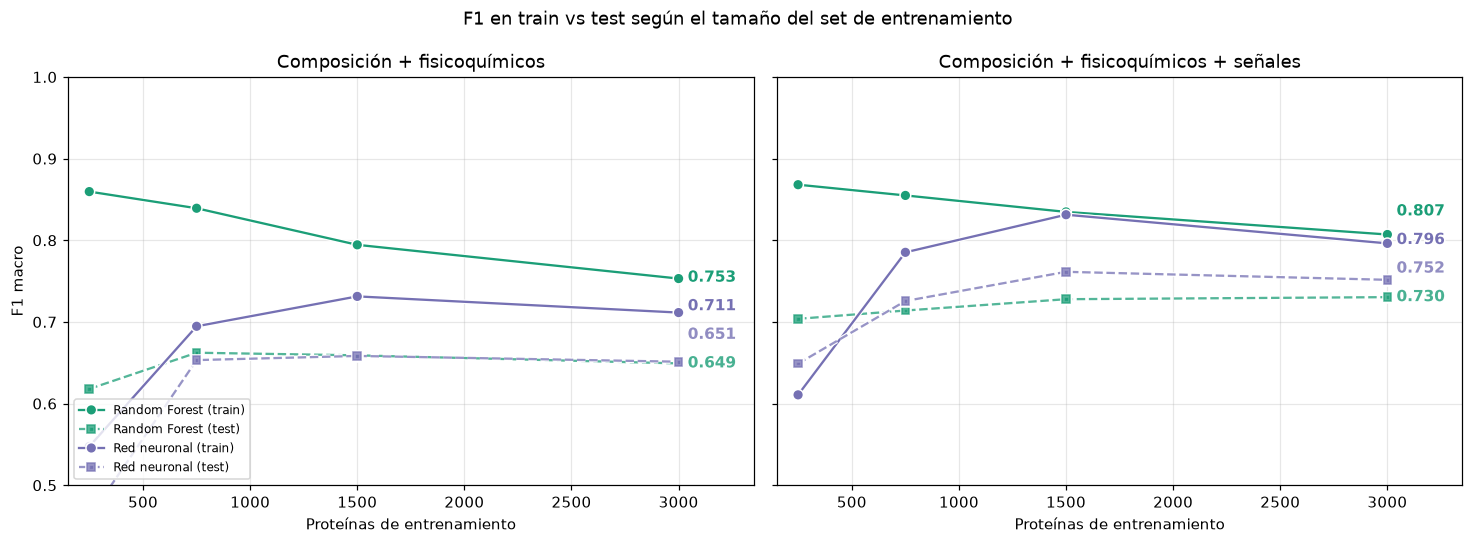

In [1]:
import matplotlib.patheffects as pe

COLORES = {"Random Forest": "#1b9e77", "Red neuronal": "#7570b3"}
ESTILOS = {"train": ("-", "o", 1.0), "test": ("--", "s", 0.75)}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)
for ax, rep in zip(axes, REPRESENTACIONES):
    sub = resultados[resultados["representacion"] == rep]
    extremos = []
    for nombre_modelo, color in COLORES.items():
        d = sub[sub["modelo"] == nombre_modelo].sort_values("n_train")
        for sufijo, (estilo, marcador, alpha) in ESTILOS.items():
            ax.plot(d["n_train"], d[f"F1_{sufijo}"], estilo, color=color, alpha=alpha,
                    marker=marcador, markersize=5, label=f"{nombre_modelo} ({sufijo})",
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])
            extremos.append([d["n_train"].iloc[-1], d[f"F1_{sufijo}"].iloc[-1],
                             d[f"F1_{sufijo}"].iloc[-1], color, alpha])
    extremos.sort(key=lambda e: e[2])
    for i in range(1, len(extremos)):
        if extremos[i][2] - extremos[i - 1][2] < 0.035:
            extremos[i][2] = extremos[i - 1][2] + 0.035
    for x, valor, y, color, alpha in extremos:
        ax.annotate(f"{valor:.3f}", xy=(x, y), xytext=(6, 0), textcoords="offset points",
                    color=color, alpha=alpha, fontsize=10, fontweight="bold",
                    va="center", ha="left",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])
    ax.set_title(rep)
    ax.set_xlabel("Proteínas de entrenamiento")
    ax.set_xlim(150, 3350)
    ax.set_ylim(0.5, 1.0)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("F1 macro")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("F1 en train vs test según el tamaño del set de entrenamiento")
plt.tight_layout()
plt.show()

## Para pensar

1. ¿Qué modelo muestra la brecha train–test más grande? ¿Cómo cambia esa brecha al pasar de 250 a 3000 proteínas de entrenamiento?
2. ¿La representación *composición + fisicoquímicos + señales* mejora el F1 de test respecto a *composición + fisicoquímicos* sola? ¿En todos los modelos?
3. ¿Por qué un F1 de train alto no garantiza que el modelo sea bueno? ¿Qué habría que mirar para decidirlo?
4. ¿Qué estrategias usamos para reducir el overfitting de cada modelo (un mínimo de muestras por hoja en el Random Forest, regularización L2 y early stopping en la red neuronal)? ¿Regularizar un modelo lo hace *mejor* o sólo más *honesto*?